In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os
#image data generator is the package to lable the images & it will automatically lable all the images

In [7]:
img = image.load_img(r'/content/drive/MyDrive/CNN-Happy-Sad/training/happy/h.jpeg')

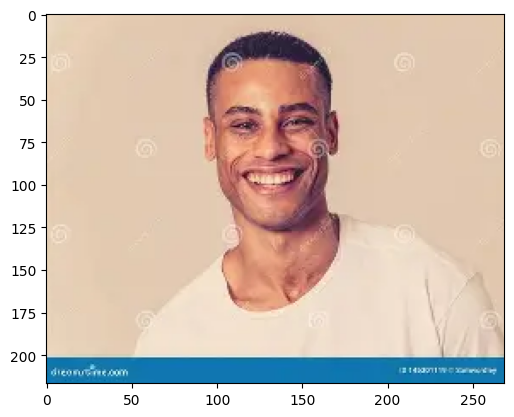

In [8]:
plt.imshow(img)

array([[[195, 218, 237],
        [195, 218, 237],
        [195, 218, 237],
        ...,
        [179, 205, 230],
        [180, 206, 232],
        [185, 208, 234]],

       [[195, 218, 237],
        [195, 218, 237],
        [195, 218, 237],
        ...,
        [177, 203, 228],
        [178, 204, 229],
        [183, 206, 232]],

       [[195, 218, 237],
        [195, 218, 237],
        [195, 218, 237],
        ...,
        [176, 201, 227],
        [177, 203, 228],
        [181, 204, 230]],

       ...,

       [[189, 123,  13],
        [184, 121,  11],
        [182, 120,  14],
        ...,
        [177, 121,  18],
        [177, 121,  18],
        [178, 122,  20]],

       [[192, 124,  14],
        [186, 121,  11],
        [184, 120,  14],
        ...,
        [177, 121,  18],
        [177, 121,  18],
        [180, 123,  21]],

       [[190, 126,  18],
        [184, 120,  14],
        [182, 119,  16],
        ...,
        [178, 123,  18],
        [178, 123,  18],
        [182, 125,  23]]], dtype=uint8)
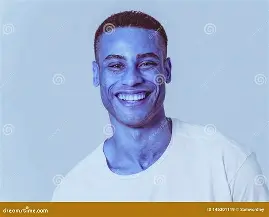

In [9]:
i1 = cv2.imread(r'/content/drive/MyDrive/CNN-Happy-Sad/training/happy/h.jpeg')
i1

In [10]:
i1.shape

(217, 269, 3)

In [12]:
train = ImageDataGenerator(rescale = 1/200)
validataion = ImageDataGenerator(rescale = 1/200)

In [13]:
train_dataset = train.flow_from_directory(r'/content/drive/MyDrive/CNN-Happy-Sad/training',
                                         target_size = (200,200),
                                         batch_size = 3,
                                         class_mode = 'binary')
validataion_dataset = validataion.flow_from_directory(r'/content/drive/MyDrive/CNN-Happy-Sad/validation',
                                          target_size = (200,200),
                                          batch_size = 3,
                                          class_mode = 'binary')

Found 10 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [22]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [23]:
train_dataset.classes

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [28]:
model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

In [33]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

In [41]:
model_fit = model.fit(train_dataset,epochs=20)




Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.8000 - loss: 0.5452
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - accuracy: 0.8000 - loss: 0.4390
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step - accuracy: 0.9000 - loss: 0.3735
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.7000 - loss: 0.3786
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.9000 - loss: 0.1671
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 1.0000 - loss: 0.0797
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - accuracy: 1.0000 - loss: 0.0224
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 712ms/step - accuracy: 1.0000 - loss: 0.0116
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 1.0000 - loss: 0.0077
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 0.0041
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - accuracy: 1.0000 - loss: 0.0027
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 1.0000 - lo

In [42]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,717,764 (132.44 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,358,883 (66.22 MB)

In [43]:
dir_path = r'/content/drive/MyDrive/CNN-Happy-Sad/testing'
for i in os.listdir(dir_path ):
    print(i)

h1.jpg
h.jpeg
h2.jpeg
s1.jpeg
s2.jpeg
s3.jpeg


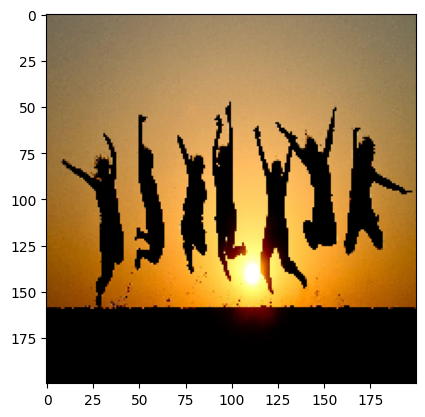

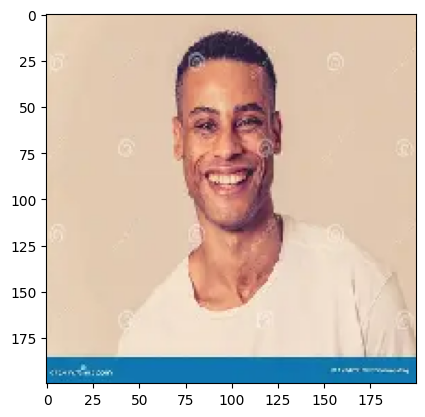

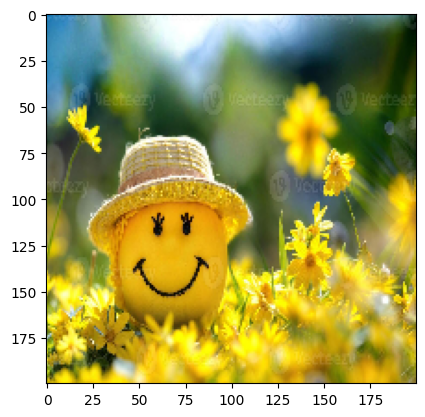

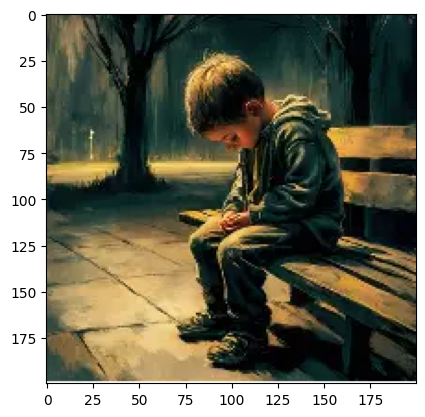

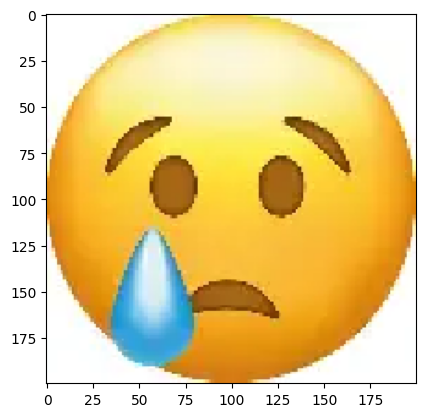

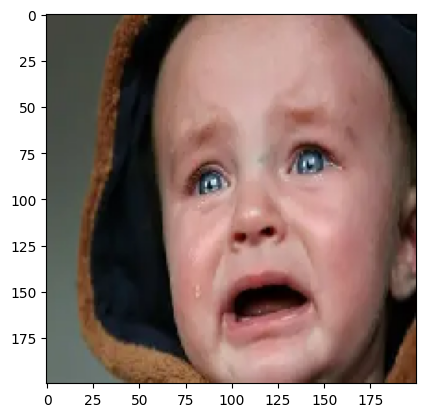

In [44]:
dir_path = r'/content/drive/MyDrive/CNN-Happy-Sad/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

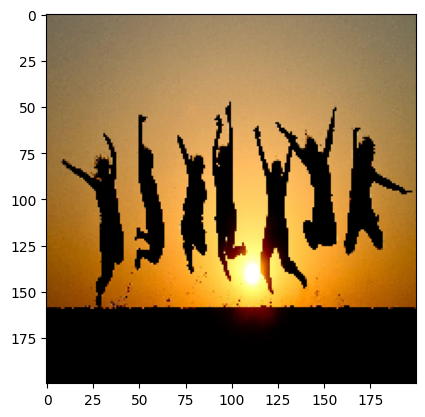

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
 i am not happy


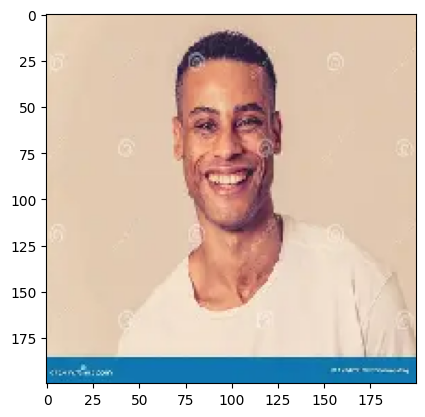

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
 i am not happy


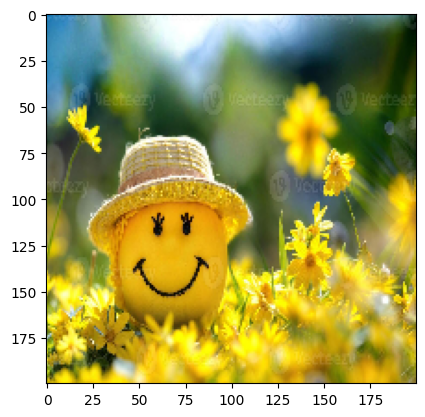

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
 i am not happy


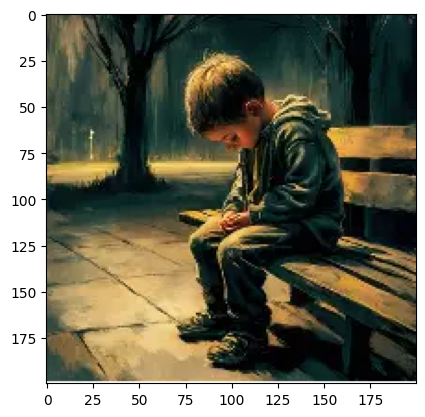

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
i am happy


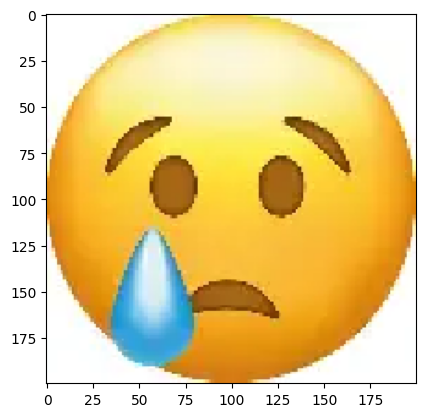

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
i am happy


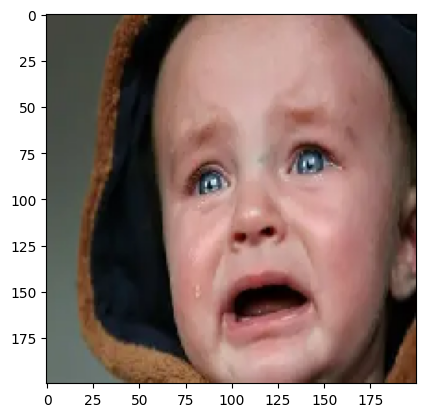

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
i am happy


In [45]:
dir_path = r'/content/drive/MyDrive/CNN-Happy-Sad/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print( ' i am not happy')
    else:
        print('i am happy')

In [47]:
import gradio as gr
from PIL import Image
import numpy as np

def predict_mood(image):
    # Resize the image to (200, 200) as expected by the model
    img = image.resize((200, 200))
    # Convert the image to a numpy array
    x = np.array(img)
    # Expand dimensions to create a batch of 1 image
    x = np.expand_dims(x, axis=0)
    # Normalize the image (if the model was trained with normalized inputs)
    # The model was trained with rescale=1/200, so we should apply the same scaling here.
    x = x / 200.0
    # Make prediction
    val = model.predict(x)[0][0]
    # Interpret the prediction
    if val < 0.5:
        return 'Happy'
    else:
        return 'Not Happy'


In [50]:
import gradio as gr

iface = gr.Interface(
    fn=predict_mood,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=gr.Text(label="Predicted Mood")
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d0e354cbef327ff4fb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
